# Guarding 1.5D Terrains

In [2]:
import os
import torch
import numpy as np

from skgeom import *
from skgeom.draw import draw

import matplotlib.pyplot as plt
from pathlib import Path

import pandas as pd

from typing   import Tuple


from data_types import VisSample 
from evaluate   import terrain_demo



# Datasets

1.5D terrain is represented as set of points and indexed set of guards that guard the points. Optimal sets of guards are computed using Gurobi solver. 



# Model

Model is tranied as an Encoder-Decoder LSTM based architecture using ideas from pointer networks. 

In [2]:
# availiable device
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

# Training

 Model is trained on our dataset of 10000 samples of sizes 5,10,15.

# Evaluation

Model is evaluated following the coverage metrics, i.e ratio of predicted and optimal coverage.

In [3]:
from evaluate import sample_coverage, terrain_demo

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
result_dir  = 'results/walk'
models_dir  = './trained_models' 

Find best evaluated model.

In [ ]:
# find best model
dev_dir = os.path.join(dataset_dir,'dev')
sizes = list(map(int,os.listdir(dev_dir)))

# define model directory
models = [
    'ne-50_bs-128_hs-256_hv-256_wd-0.01_lr-0.001_bidirectional',
    'ne-50_bs-128_hs-256_hv-256_wd-0.01_lr-0.001'    
]


# pretrained parallel model
"""
models = [
    'retrained_unidirectional',
    'retrained_bidirectional',
    'retrained_unidirectional_parallel',
    'retrained_bidirectional_parallel'
]
"""

for m in models:
    model_dir = os.path.join(models_dir,m)

    # find best model directory
    best_model_dir,best_model_name = models_dir,model_dir.rpartition('/')[-1]
    models = os.listdir(model_dir)

    model_eval = dict()

    best_eval = 0.0
    best_model = None

    sizes = ['5','10','15','20','30','40','50']
    sample_size = 100

    for model_name in models:
        if model_name == best_model_name : continue    
        model = torch.load(os.path.join(model_dir,model_name))    
        samples = [VisSample.read_samples(path=os.path.join(dev_dir,f'{size}'),normalize=True)[:sample_size] for size in sizes]
        print(f'\nEvaluating model {model_name}')
        model_eval[model_name] = np.sum([sample_coverage(model,sample)[0] for sample in samples])
        if model_eval[model_name] > best_eval:
            best_eval = model_eval[model_name]
            best_model = model_name


    model = torch.load(os.path.join(model_dir,best_model))
    torch.save(model, os.path.join(best_model_dir, best_model_name+'.pt'))

    print(f'Best model for {m}: {best_model}, validation loss: {best_eval}')

List of available models.

In [ ]:
# model for terrain
# scaled
walk_unidir    = os.path.join(models_dir,'ne-50_bs-128_hs-256_hv-256_wd-0.01_lr-0.001.pt')
walk_bidir     = os.path.join(models_dir,'ne-50_bs-128_hs-256_hv-256_wd-0.01_lr-0.001_bidirectional.pt')

# normalized
walk_unidir_normalized     = os.path.join(models_dir,'ne-100_bs-128_hs-256_hv-256_wd-0.01_lr-0.001_normalized.pt')
walk_bidir_normalized      = os.path.join(models_dir,'ne-100_bs-128_hs-256_hv-256_wd-0.01_lr-0.001_bidirectional_normalized.pt')

# transfer learning model, normalized
transfer_walk_bidir = os.path.join(models_dir,'retrained_bidirectional.pt')
transfer_walk_unidir = os.path.join(models_dir,'retrained_unidirectional.pt')

# transfer learning model, normalized, seq2mseq-parallel
transfer_walk_unidir_par = os.path.join(models_dir,'retrained_unidirectional_parallel.pt')
transfer_walk_bidir_par = os.path.join(models_dir,'retrained_bidirectional_parallel.pt')

# latest
model_less_epochs = os.path.join(models_dir,'model_epoch_10.pt')

In [ ]:
def test_model_per_size(model_name : str, test_dir : str, beam_width: int = None, alpha: float = None, beta: float = None) -> pd.DataFrame:
    # load model
    model = torch.load(model_name)
   
    dfs = []
    # sizes = sorted(list(map(int,os.listdir(test_dir))))
    sizes = [200]
    for  size in sizes: 
        
        samples = VisSample.read_samples(path=os.path.join(test_dir,f'{size}'))     
        results = sample_coverage(model, samples, beam_width, alpha, beta)
        
        data = {'size' : [size], 'coverage' : results[0], 'approx' : results[1]}
        dfs.append(pd.DataFrame(data))   
        
    df = pd.concat(dfs).set_index('size').sort_index()
    df.to_json(os.path.join(result_dir,f'{Path(model_name).stem}.json'))

    return df


def test_model(model_name : str, test_dir : str, beam_width: int = None, alpha: float = None, beta: float = None) -> pd.DataFrame:
    model = torch.load(model_name)
   
    dfs = []
    #sizes = sorted(list(map(int,os.listdir(test_dir))))
    instances = [f for f in test_dir if os.path.isfile(f)]
    print(instances)

    for  instance in instances: 
        samples = VisSample.read_samples(path=os.path.join(test_dir,f'{instance}'))     
        results = sample_coverage(model, samples, beam_width, alpha, beta)
        
        data = {'instance' : [instance], 'coverage' : results[0], 'approx' : results[1]}
        dfs.append(pd.DataFrame(data))   
        
    df = pd.concat(dfs).set_index('size').sort_index()
    df.to_json(os.path.join(result_dir,f'{Path(model_name).stem}.json'))

    return df



def compare_results(dfs : Tuple) -> None:
    plt.rcParams["figure.figsize"] = [20.50, 10.50]
    plt.rcParams["figure.autolayout"] = True

    # read results
    df1,  df2 = dfs[0], dfs[1]


    fig, ax = plt.subplots(2, 2)
    bbox = [0, 0, 1, 1]
    t1 = ax[0][0].table(cellText=df1.values,colLabels=df1.columns,rowLabels=df1.index, bbox = bbox,cellLoc='left')
    ax[0][0].axis('off')
    t2 = ax[0][1].table(cellText=df2.values,colLabels=df2.columns,rowLabels=df2.index, bbox = bbox,cellLoc='left')
    ax[0][1].axis('off')    
    ax[0][0].set_title("PtrNet-unidirectional")
    ax[0][1].set_title("PtrNet-bidirectional")
    ax[1][0].set_title("coverage comparison")
    ax[1][0].plot(df1[df1.columns[0]])
    ax[1][0].plot(df2[df2.columns[0]])
    ax[1][0].set_ylim(0,1.1)
    ax[1][0].legend(['PtrNet-unidir','PtrNet-bidir'])
    ax[1][1].set_title("approx comparison")
    ax[1][1].plot(df1[df1.columns[1]])
    ax[1][1].plot(df2[df2.columns[1]])
    ax[1][1].set_ylim(0,3)
    ax[1][1].legend(['PtrNet-unidir','PtrNet-bidir'])
    plt.show()






def lcs_length(a, b):
    table = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i, ca in enumerate(a, 1):
        for j, cb in enumerate(b, 1):
            table[i][j] = (
                table[i - 1][j - 1] + 1 if ca == cb else
                max(table[i][j - 1], table[i - 1][j]))
    return table[-1][-1]


def precision(model_name : str,instance : str, beam_width : int = 4, alpha : float = 0.7, beta : float = None):
    model = torch.load(model_name)    
    sample = TerrainSample.read_samples(path=instance)[0]
      
    predicted = terrain_predict(model, sample, beam_width, alpha,beta).tolist()
         
    
    solutions =[ t.guards.tolist() for t in TerrainSample.read_samples(path=instance,sol_sample=0) ]

    # find max ratio value and opt
    max_ratio = 0
    for opt in solutions:
        ratio = lcs_length(predicted,opt)/max(len(predicted),len(opt))
        if ratio > max_ratio: 
            max_ratio = ratio
            max_opt   = opt

    
    return predicted, max_opt, max_ratio





In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk/'
instance = os.path.join(dataset_dir,'test/50/walk-50-04.terrain')

precision(transfer_walk_unidir,instance)

([4, 16, 23, 28, 40, 47], [4, 6, 15, 23, 28, 36, 40, 48], 0.5)

## Experiments

## `walk` instances



### testbed `walk.1`:
* instance sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation
* scaled by max magnitude, beam search, epochs 100
 

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
walk_1 = test_model_per_size(walk_unidir, test_dir, beam_width=4, alpha=0.7), test_model_per_size(walk_bidir, test_dir, beam_width=4, alpha=0.7)

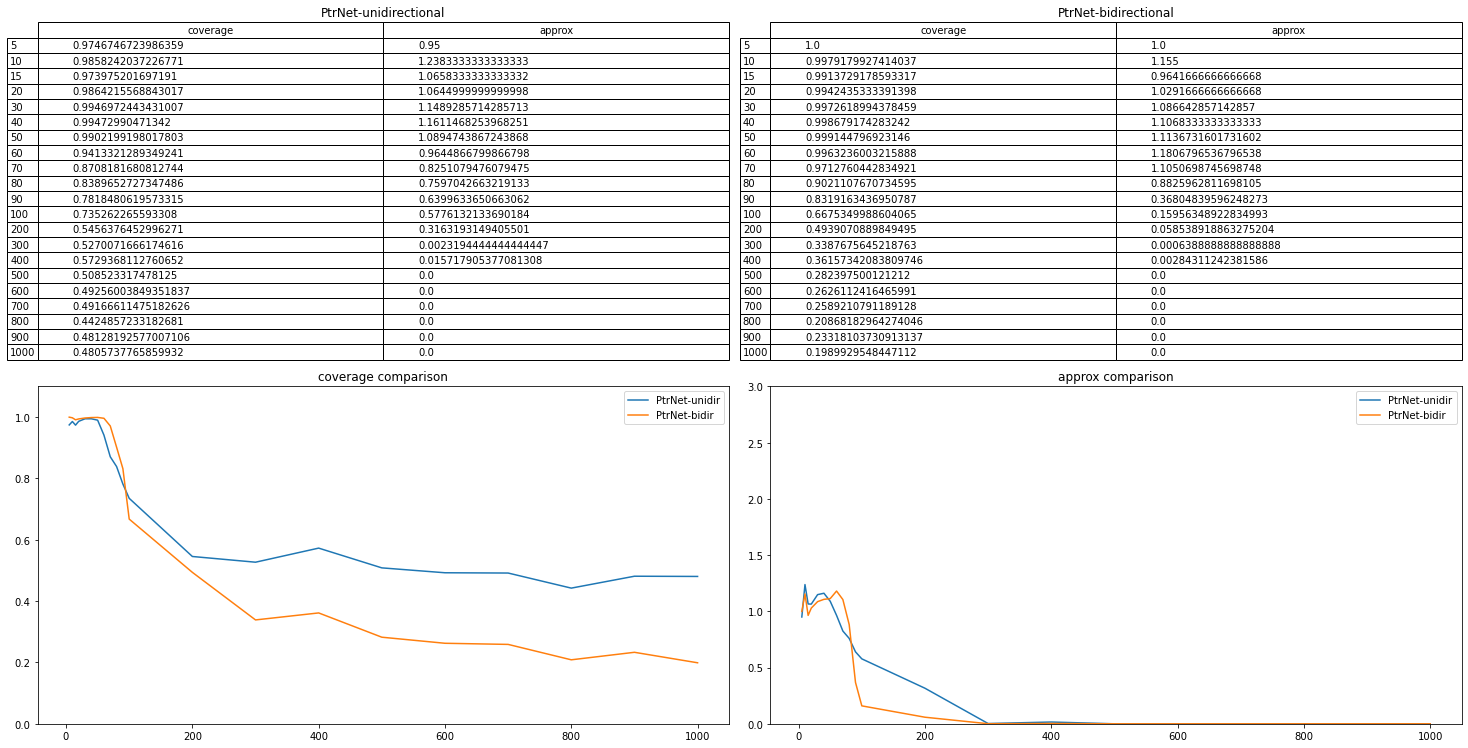

In [9]:
compare_results(walk_1)

### testbed `walk.2`:
* instance sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 test, 3000 validation
* normalized, beam search

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
walk_2 = test_model_per_size(walk_unidir_normalized, test_dir, beam_width=4, alpha=0.7), test_model_per_size(walk_bidir_normalized, test_dir, beam_width=4, alpha=0.7)

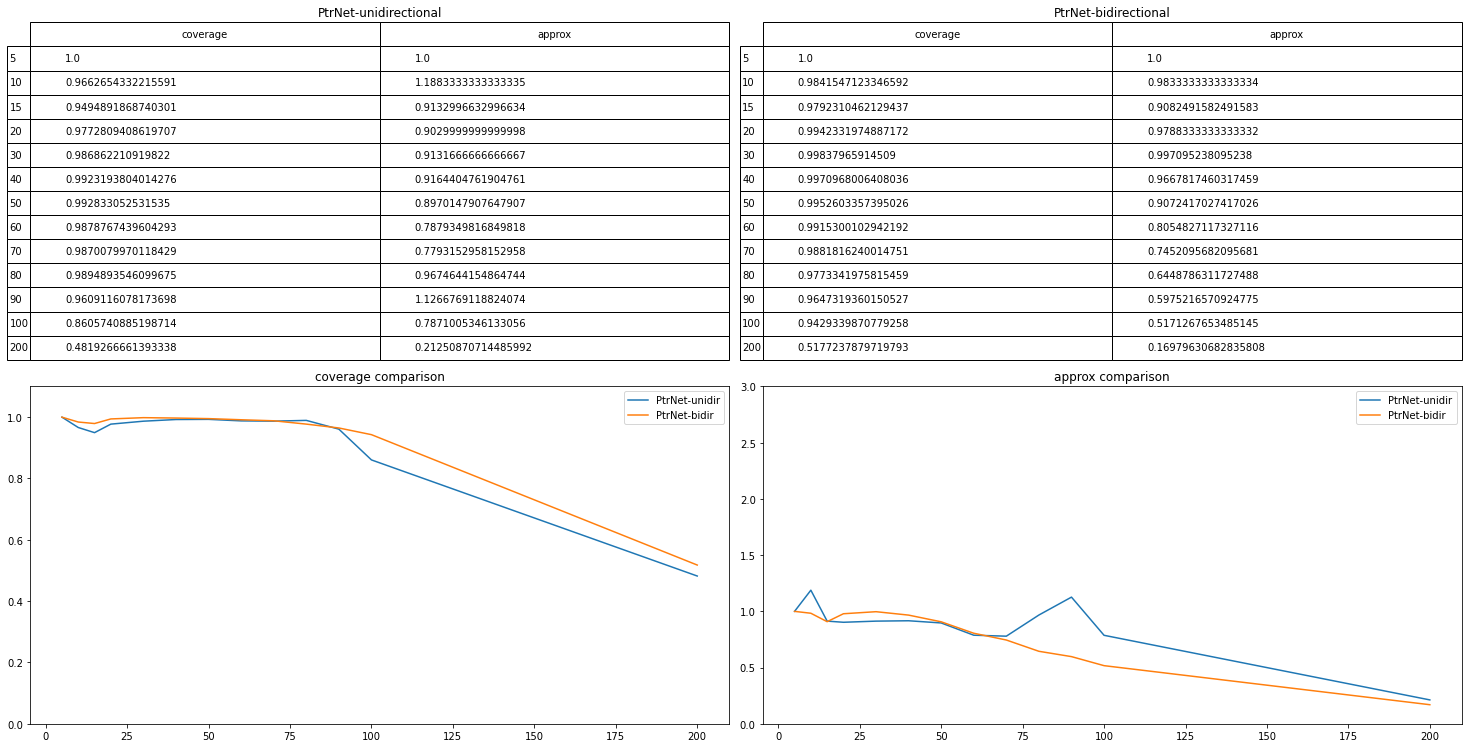

In [ ]:
compare_results(walk_2)

### testbed `walk.3`:
* transfer learning from CH
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation
* normalized, beam search
 

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
walk_3 = test_model_per_size(transfer_walk_unidir, test_dir, beam_width=4, alpha=0.7), test_model_per_size(transfer_walk_bidir, test_dir, beam_width=4, alpha=0.7)

Processing instance walk-1000-99 

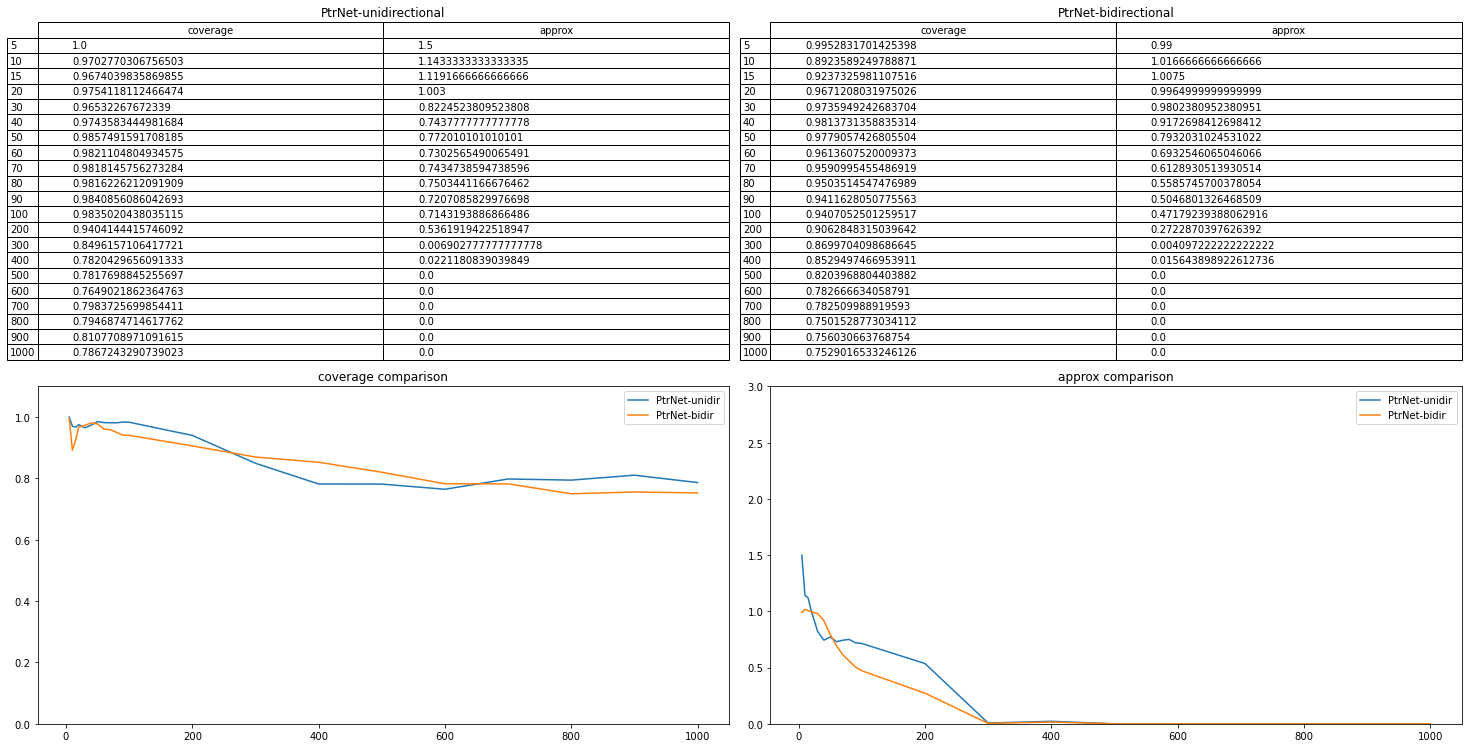

In [ ]:
compare_results(walk_3)

### testbed `walk.4`:
* transfer learning from CH on **seq2mseq-parallel**
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation up to 10 extra solutions per sample
* normalized, beam search
 

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
walk_4 = test_model_per_size(transfer_walk_unidir_par, test_dir, beam_width=4, alpha=0.7), test_model_per_size(transfer_walk_bidir_par, test_dir, beam_width=4, alpha=0.7)

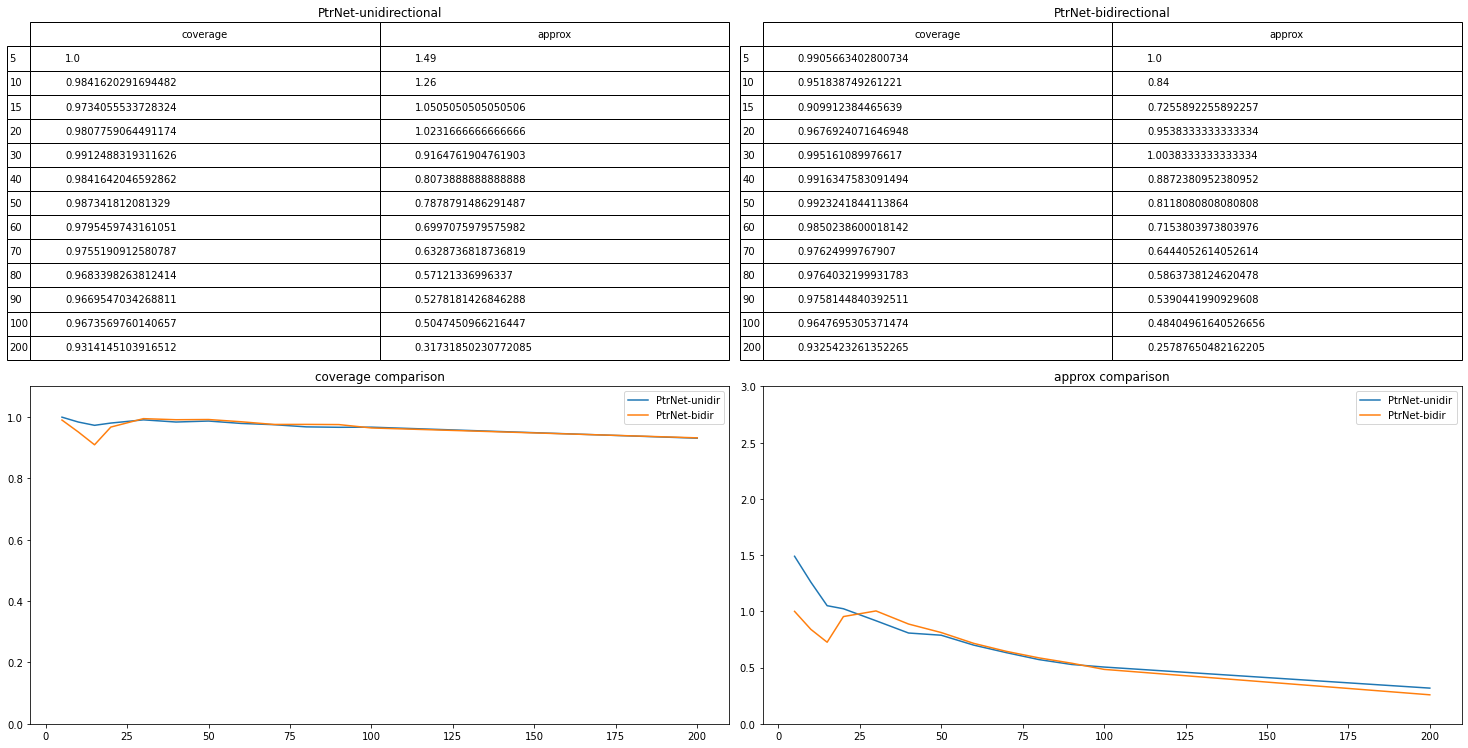

In [ ]:
compare_results(walk_4)

### testbed `walk.5`:
* transfer learning from CH 
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation up to 10 extra solutions per sample
* normalized, beam search with value function
 

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
walk_5 = test_model_per_size(transfer_walk_unidir, test_dir, beam_width=4, alpha=0.7,beta=0.2), test_model_per_size(transfer_walk_bidir_par, test_dir, beam_width=4, alpha=0.7)

### testbed `walk.6`:
* transfer learning from CH 
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 
* normalized, small number of epochs: 10
 

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'
# test dataset
test_dir = os.path.join(dataset_dir,'test/50/')

# testing
walk_6 = test_model(model_less_epochs, test_dir, beam_width=4, alpha=0.7,beta=0.00002)

## `sinewalk` instance:

testbed `sinewalk.1`
* transfer learning from CH
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* instance sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation
* normalized, beam search

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/sinewalk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
sinewalk_1 = test_model_per_size(transfer_walk_unidir, test_dir, beam_width=4, alpha=0.7), test_model_per_size(transfer_walk_bidir, test_dir, beam_width=4, alpha=0.7)

Processing instance sinewalk-1000-99 

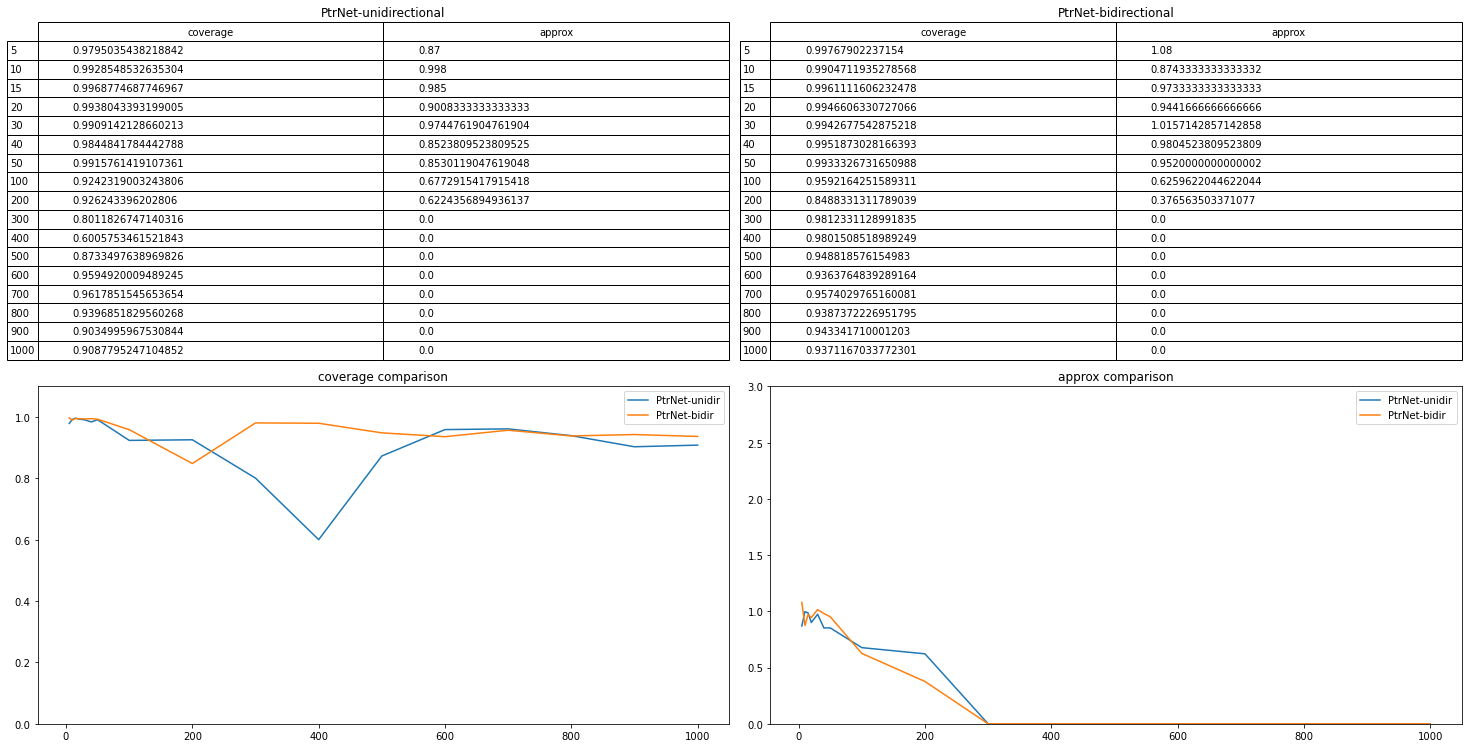

In [ ]:
compare_results(sinewalk_1)

# `parabolawalk` instance:

testbed `parabolawalk.1`
* transfer learning from CH
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* instance sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation
* normalized, beam search

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/parabolawalk'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
parabolawalk_1 = test_model_per_size(transfer_walk_unidir, test_dir, beam_width=4, alpha=0.7), test_model_per_size(transfer_walk_bidir, test_dir, beam_width=4, alpha=0.7)

Processing instance parabolawalk-1000-99 

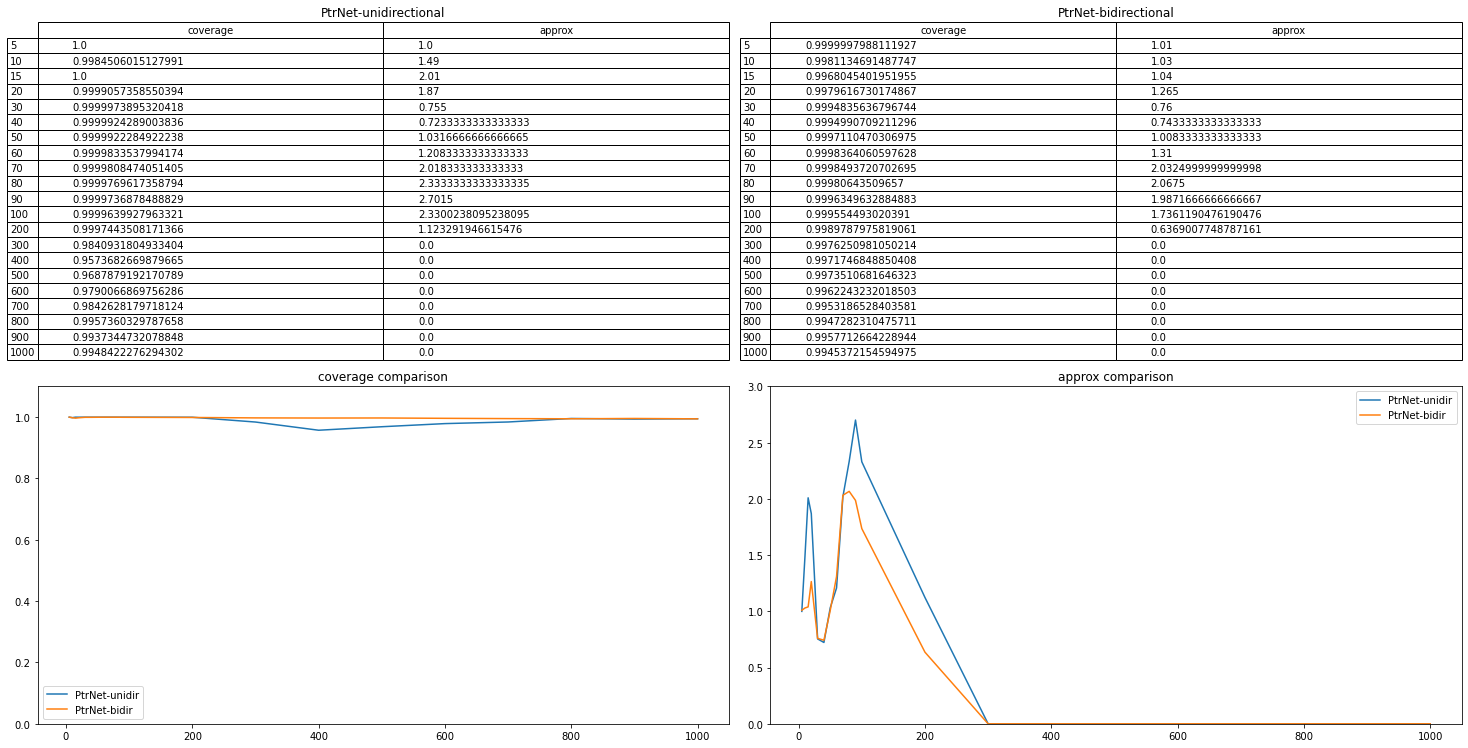

In [ ]:
compare_results(parabolawalk_1)

## `concavevalleys` instance:

testbed `concavevalleys.1`
* transfer learning from CH
* fine-tuning on `walk` instances sizes: 5,10,15,20,30,40,50
* instance sizes: 5,10,15,20,30,40,50
* no. of samples = 7000 train, 3000 validation
* normalized, beam search

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/concavevalleys'
# test dataset
test_dir = os.path.join(dataset_dir,'test')

# testing
concvalleys_1 = test_model_per_size(transfer_walk_unidir, test_dir, beam_width=4, alpha=0.7), test_model_per_size(transfer_walk_bidir, test_dir, beam_width=4, alpha=0.7)

Processing instance concavevalleys-60-98 Problem on concavevalleys-60-98
CGAL ERROR: precondition violation!
Expr: Base::number_of_outer_ccbs() == 1
File: /opt/anaconda3/include/CGAL/Arrangement_on_surface_2.h
Line: 840
Processing instance concavevalleys-200-97 Problem on concavevalleys-200-97
CGAL ERROR: precondition violation!
Expr: Base::number_of_outer_ccbs() == 1
File: /opt/anaconda3/include/CGAL/Arrangement_on_surface_2.h
Line: 840


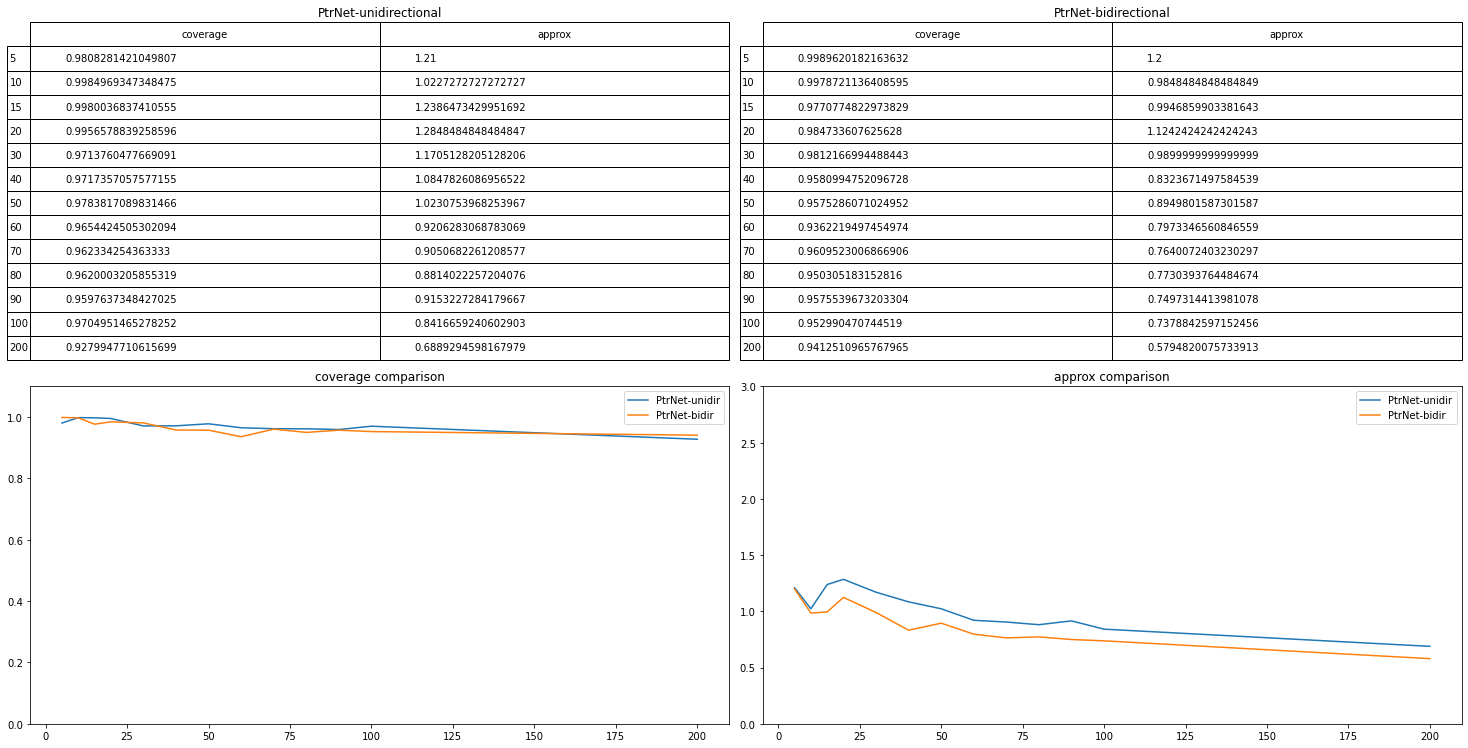

In [ ]:
compare_results(concvalleys_1)

___

# Testing instances



## Question 1: is it the same as doing greedy search?

**Remark**: How much greedy strategy dominates on small vs. large instances.

In [ ]:
plt.rcParams["figure.figsize"] = [6.4,4.8]
plt.rcParams["figure.autolayout"] = True

In [ ]:
from evaluate import Opt, TGNetSearch, TGreedy


TGNet


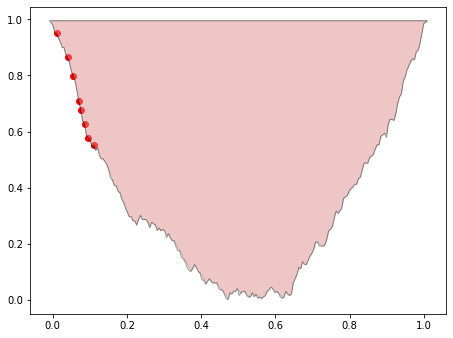

TGNet less epochs


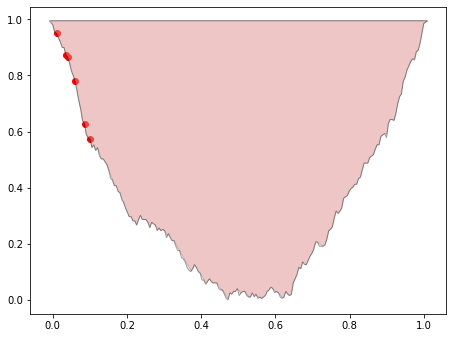

Greedy search


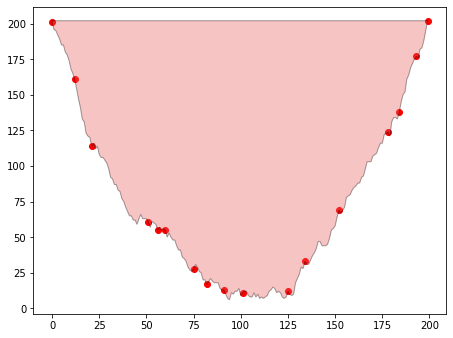

Optimal


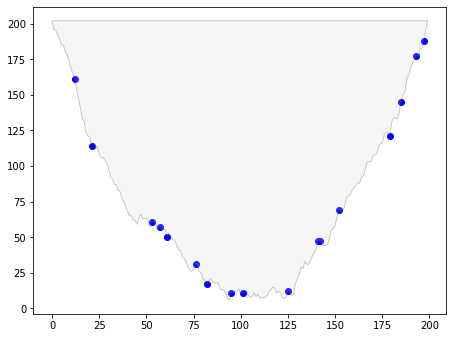

TGNet coverage:     0.99781175,      approx: 0.47058824
TGNet-le coverage:  0.99778303,      approx: 0.35294118
Greedy coverage:    1.00000000,      approx: 1.00000000


In [ ]:
# data
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/parabolawalk'
instances = ['']
instance = os.path.join(dataset_dir,'test/200/parabolawalk-200-05.terrain')

#opt value
opt = Opt()
# PTrNet search
ns_le = TGNetSearch(model_less_epochs)
ns    = TGNetSearch(walk_unidir_normalized)

# greedy search
gs = TGreedy()

# prediction
sol_opt    = opt.predict(instance)
sol_ns     = ns.predict(instance,beam_width=1,beta=0.000001)
sol_ns_le  = ns_le.predict(instance,beam_width=1,beta=0.000001)
sol_gs     = gs.predict(instance,1.0)

print('TGNet')
ns.show()
print('TGNet less epochs')
ns_le.show()
print('Greedy search')
gs.show()    
print('Optimal')
opt.show()


print(f'TGNet coverage:     {ns.coverage:2.8f},      approx: {len(sol_ns)/len(sol_opt):2.8f}')
print(f'TGNet-le coverage:  {ns_le.coverage:2.8f},      approx: {len(sol_ns_le)/len(sol_opt):2.8f}')
print(f'Greedy coverage:    {gs.coverage:2.8f},      approx: {len(sol_gs)/len(sol_opt):2.8f}')

In [ ]:
from pathlib import Path
import random


def sample_files(path : str, no_samples : int) -> list:
    pathlist = Path(path).glob('*.terrain')

    rc = []
    for k, p in enumerate(pathlist):
        if k < no_samples: 
            rc.append(str(p))
        else: 
            i = random.randint(0,k)
            if i < no_samples:
                rc[i] = str(p)
    return rc



def compare_solve(model_name : str, instances : list, beam_width: int = None, alpha: float = None, beta: float = None) -> pd.DataFrame:
    # load model
    model = torch.load(model_name)
    no_data = len(instances)
    #opt value
    opt = Opt()
    # PTrNet search
    ns = TGNetSearch(transfer_walk_unidir)
    # greedy search
    gs = GreedySearch()

    ns_results = np.zeros((no_data,2))
    gs_results = np.zeros((no_data,2))


    for i,instance in enumerate(instances):
        # avgs
        sol_opt = opt.predict(instance)
        sol_ns  = ns.predict(instance,beam_width=1,alpha=alpha,beta=beta)
        sol_gs  = gs.predict(instance,ns.coverage)

        ns_results[i] = ns.coverage,   len(sol_ns)/len(sol_opt)
        gs_results[i]   = gs.coverage, len(sol_gs)/len(sol_opt)
        

    print(f'no. samples: {no_data}')
    print(f'TGNet:  avg. coverage: {np.average(ns_results[:,0]):2.8f}, avg. approx: {np.average(ns_results[:,1])}')
    print(f'Greedy: avg. coverage: {np.average(gs_results[:,0]):2.8f}, avg. approx: {np.average(gs_results[:,1])}')




In [ ]:
instances = sample_files('/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk/test/50',30)


In [ ]:
sizes = [5,10,20,30,40,50]; no_samples = 30


for size in sizes:    
    instances = sample_files(f'/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk/test/{size}',no_samples)

    # MLE dominated    
    alpha, beta = 1, 1e-7
    print('\r*********************************************************************************************')
    print(f' * size: {size}, alpha: {alpha}, beta: {beta}')    
    print('\r---------------------------------------------------------------------------------------------')   
    compare_solve(transfer_walk_unidir,instances, beam_width=1,alpha=alpha,beta=beta)

    # greedy dominated
    alpha,beta = alpha, 1-beta
    print('\r---------------------------------------------------------------------------------------------')
    print(f' * size: {size}, alpha: {alpha}, beta: {beta}')    
    compare_solve(transfer_walk_unidir,instances, beam_width=1,alpha=alpha,beta=beta)

    
    


*********************************************************************************************
 * size: 5, alpha: 1, beta: 1e-07
---------------------------------------------------------------------------------------------
no. samples: 30
TGNet:  avg. coverage: 0.95170264, avg. approx: 1.1333333333333333
Greedy: avg. coverage: 1.00000000, avg. approx: 1.0
---------------------------------------------------------------------------------------------
 * size: 5, alpha: 1, beta: 0.9999999
no. samples: 30
TGNet:  avg. coverage: 1.00000000, avg. approx: 1.6
Greedy: avg. coverage: 1.00000000, avg. approx: 1.1
*********************************************************************************************
 * size: 10, alpha: 1, beta: 1e-07
---------------------------------------------------------------------------------------------
no. samples: 30
TGNet:  avg. coverage: 0.77492118, avg. approx: 0.9166666666666666
Greedy: avg. coverage: 0.97785121, avg. approx: 0.8333333333333334
------------------

In [ ]:
sizes = [60,70,80,90,100,200]; no_samples = 30

for size in sizes:    
    instances = sample_files(f'/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk/test/{size}',no_samples)

    # MLE dominated    
    alpha, beta = 1, 1e-7
    print('\r*********************************************************************************************')
    print(f' * size: {size}, alpha: {alpha}, beta: {beta}')    
    print('\r---------------------------------------------------------------------------------------------')   
    compare_solve(transfer_walk_unidir,instances, beam_width=1,alpha=alpha,beta=beta)

    # greedy dominated
    alpha,beta = alpha, 1-beta
    print('\r---------------------------------------------------------------------------------------------')
    print(f' * size: {size}, alpha: {alpha}, beta: {beta}')    
    compare_solve(transfer_walk_unidir,instances, beam_width=1,alpha=alpha,beta=beta)

*********************************************************************************************
 * size: 60, alpha: 1, beta: 1e-07
---------------------------------------------------------------------------------------------
no. samples: 30
TGNet:  avg. coverage: 0.97163962, avg. approx: 0.7175470825470825
Greedy: avg. coverage: 0.97897494, avg. approx: 0.5265089540089539
---------------------------------------------------------------------------------------------
 * size: 60, alpha: 1, beta: 0.9999999
no. samples: 30
TGNet:  avg. coverage: 1.00000000, avg. approx: 1.23001591001591
Greedy: avg. coverage: 1.00000000, avg. approx: 0.9903671328671327
*********************************************************************************************
 * size: 70, alpha: 1, beta: 1e-07
---------------------------------------------------------------------------------------------
no. samples: 30
TGNet:  avg. coverage: 0.97129574, avg. approx: 0.7502064602064603
Greedy: avg. coverage: 0.97638794, avg. 

## Case 2: concave valleys

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/concavevalleys'


model = torch.load(transfer_walk_unidir)
samples = TerrainSample.read_samples(path = os.path.join(dataset_dir,'test/90'),normalize=True)

sample = samples[4]
poly,region, predicted, opt,coverage = terrain_demo(model,sample,beam_width=10,alpha=0.7)

## Testing solution 

Interesting comparison: `test/500/walk-500-09.terrain` vs `test/500/walk-500-10.terrain`

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/TGPIL/my_walk'


model = torch.load(transfer_walk_unidir)
samples = TerrainSample.read_samples(path = os.path.join(dataset_dir,'test/500/walk-500-10.terrain'),normalize=True)

sample = samples[0]
poly,region, predicted, opt,coverage = terrain_demo(model,sample,beam_width=4,alpha=0.7)

coverage


0.6072626606099558

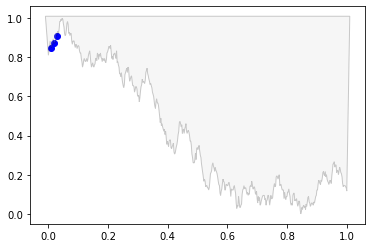

In [ ]:
draw(poly,line_width=1,alpha=0.2,aspect_ratio = 'auto')        
draw(predicted,color = 'blue')

# Art Gallery problems

Demonstrating PointerNet on approximating visibility in polygons with vertex guards (Art Gallery problem).

In [ ]:
from terrain import polygon_demo

In [ ]:
dataset_dir = '/home/dseverdi/Radno/MLTG/dataset/AG/agp2009a_simplerand_converted'


model = torch.load(transfer_walk_unidir)
samples = VisSample.read_samples(path = os.path.join(dataset_dir,'randsimple-20-1.pol'),normalize=True)

sample = samples[0]
poly,region, predicted, opt,coverage = terrain_demo(model,sample,beam_width=10,alpha=0.7)